In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

def set_size(w,h):
  plt.rcParams["figure.figsize"] = [w,h]


In [ ]:
DMODEL   = 64
HEAD_DIM = 64
SEQ_LEN  = 32

class OneHead(nn.Module):
    def __init__(self, d=DMODEL, h=HEAD_DIM, l=SEQ_LEN):
        super().__init__()

        self.norm = nn.LayerNorm(d)

        self.Wq = nn.Linear(d, h, bias=False)
        self.Wk = nn.Linear(d, h, bias=False)
        self.Wv = nn.Linear(d, h, bias=False)
        self.Wo = nn.Linear(h, d, bias=False)

        self.pos = nn.Parameter(torch.randn(l, d) * 0.02)
        self.bos = nn.Parameter(torch.randn(d) * 0.02)

        self.mlp = nn.Identity()

    def forward(self, x, ret=False):
        x_in = x  # original input (for loss / inspection later)

        x = x.clone()
        x[:, 0, :] = x[:, 0, :] + self.bos
        x = x + self.pos.unsqueeze(0)
        x = self.norm(x)

        Q = self.Wq(x)                  # (B, L, H)
        K = self.Wk(x)                  # (B, L, H)
        V = self.Wv(x)                  # (B, L, H)

        scores = Q @ K.transpose(1, 2) / math.sqrt(Q.shape[-1])
        A = torch.softmax(scores, dim=-1)   # (B, L, L)

        O = x + self.Wo(A @ V)          # residual + attention
        #O = O + self.mlp(O)             # Identity here

        return (O, A, (Q, K, V, scores, x_in, x)) if ret else O


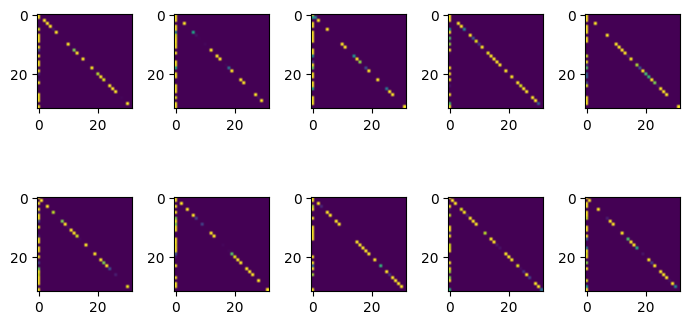

step 10000 | loss 6.713e-02 | mean attn→pos0 0.514


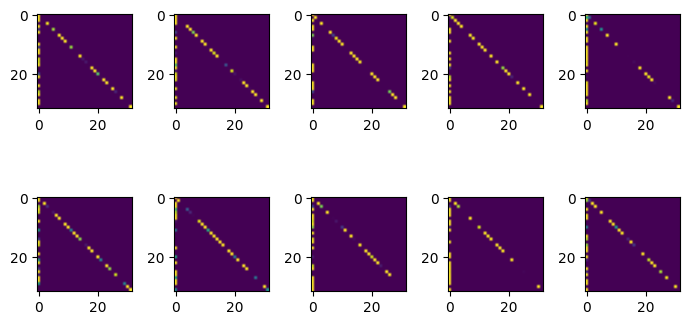

step 20000 | loss 5.710e-02 | mean attn→pos0 0.517


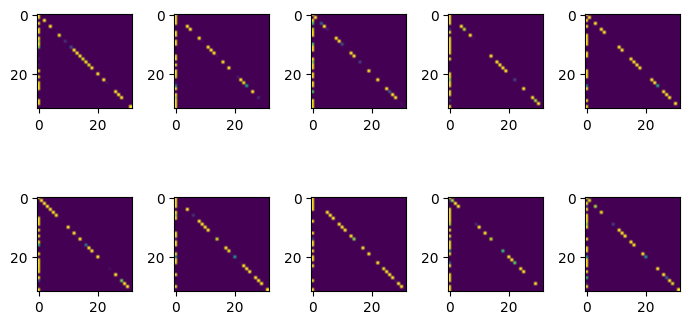

step 30000 | loss 5.737e-02 | mean attn→pos0 0.516


In [ ]:
device = "cuda"

model = OneHead().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

BATCH_SIZE = 1024
STEPS      = 30_000

# fixed gate vector v (no grad)
v_gate = torch.randn(DMODEL, device=device)
v_gate = v_gate / v_gate.norm()  # normalize just for stability

for step in range(1, STEPS + 1):
    # random token embeddings
    x = torch.randn(BATCH_SIZE, SEQ_LEN, DMODEL, device=device)

    O, A, (Q, K, V, scores, x_in, x_after_posln) = model(x, ret=True)

    # compute s = <x_in, v_gate> for each token
    # x_in: (B, L, d), v_gate: (d,) -> (B, L, 1)
    s = (x_in * v_gate).sum(dim=-1, keepdim=True)

    # mask: 1 where s > 0 (should map to zero), 0 otherwise (should be no-op)
    mask = (s > 0).float()

    # target: if mask == 1 → 0, else → x_in
    target = (1.0 - mask) * x_in  # (B, L, d)

    loss = F.mse_loss(O, target)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    if step % 10_000 == 0:
        # imshow the attention of the first ten input
        set_size(7, 4)
        for i in range(10):
            a = A[i].detach().cpu().numpy()  # (L, L)
            plt.subplot(2, 5, i + 1)
            plt.imshow(a, cmap='viridis')
        plt.tight_layout()
        plt.show()

        attn_to_0 = A[..., 0].mean().item()
        print(
            f"step {step:5d} | loss {loss.item():.3e} | "
            f"mean attn→pos0 {attn_to_0:.3f}"
        )


In [ ]:
@torch.no_grad()
def measure_avg_attention(model, n_batches=64, batch_size=128):
    model.eval()
    device = next(model.parameters()).device

    attn_sum = torch.zeros(SEQ_LEN, device=device)
    count = 0

    for _ in range(n_batches):
        x = torch.randn(batch_size, SEQ_LEN, DMODEL, device=device)
        _, A, _ = model(x, ret=True)  # A: (B, L, L)
        attn_sum += A.mean(dim=(0, 1))
        count += 1

    avg_attn = (attn_sum / count).cpu()
    return avg_attn

avg_attn = measure_avg_attention(model)
for i, v in enumerate(avg_attn):
    print(f"pos {i:2d}: {v.item():.3f}")


pos  0: 0.031
pos  1: 0.031
pos  2: 0.031
pos  3: 0.031
pos  4: 0.031
pos  5: 0.031
pos  6: 0.031
pos  7: 0.031
pos  8: 0.031
pos  9: 0.031
pos 10: 0.031
pos 11: 0.031
pos 12: 0.031
pos 13: 0.031
pos 14: 0.031
pos 15: 0.031
pos 16: 0.031
pos 17: 0.031
pos 18: 0.031
pos 19: 0.031
pos 20: 0.031
pos 21: 0.031
pos 22: 0.031
pos 23: 0.031
pos 24: 0.031
pos 25: 0.031
pos 26: 0.031
pos 27: 0.031
pos 28: 0.031
pos 29: 0.032
pos 30: 0.031
pos 31: 0.031


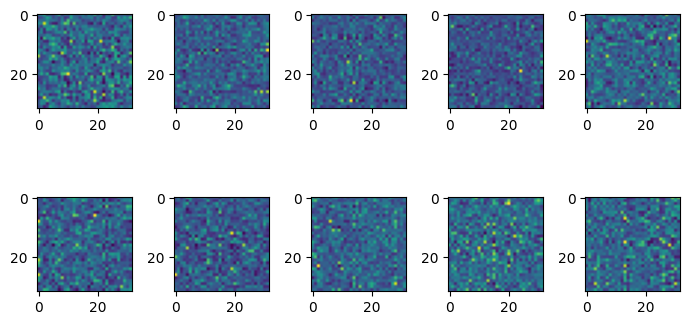

step 30000 | loss 2.329e-02 | mean attn→pos0 0.031


In [ ]:
def train_and_logs(no_op_factor = 0.0,   BATCH_SIZE=2048, STEPS=30_000):

  LOGS = {}

  device = "cuda"

  model = OneHead().to(device)
  opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

  # fixed gate vector v (no grad)
  v_gate = torch.randn(DMODEL, device=device)
  v_gate = v_gate / v_gate.norm()  # normalize just for stability

  for step in range(1, STEPS + 1):
      # random token embeddings
      x = torch.randn(BATCH_SIZE, SEQ_LEN, DMODEL, device=device)

      O, A, (Q, K, V, scores, x_in, x_after_posln) = model(x, ret=True)

      # compute s = <x_in, v_gate> for each token
      # x_in: (B, L, d), v_gate: (d,) -> (B, L, 1)
      s = (x_in * v_gate).sum(dim=-1, keepdim=True)

      mask = (s > 0).float()
      # when the mask is active results should be x_in * no_op_factor else just x_in
      target = mask * (x_in * no_op_factor) + (1.0 - mask) * x_in  # (B, L, d)
      #old target = (1.0 - mask) * x_in  # (B, L, d)

      loss = F.mse_loss(O, target)

      opt.zero_grad(set_to_none=True)
      loss.backward()
      opt.step()

      if step % 10 == 0:
          avg_attn = measure_avg_attention(model)
          LOGS[step] = {
              'avg_attn': avg_attn.numpy(),
          }

      if step % 10_000 == 0:
          # imshow the attention of the first ten input
          set_size(7, 4)
          for i in range(10):
              a = A[i].detach().cpu().numpy()  # (L, L)
              plt.subplot(2, 5, i + 1)
              plt.imshow(a, cmap='viridis')
          plt.tight_layout()
          plt.show()

          attn_to_0 = A[..., 0].mean().item()
          print(
              f"step {step:5d} | loss {loss.item():.3e} | "
              f"mean attn→pos0 {attn_to_0:.3f}"
          )

  return LOGS

RESULTS = {}
for no_op in [0.0, 1e-3, 1e-2, 1e-1, 0.5, 1.0]:
  logs = train_and_logs(no_op_factor=no_op, BATCH_SIZE=2048, STEPS=30000)
  RESULTS[no_op] = logs

In [ ]:
torch.save(RESULTS, "data/toy_no_op_factor.pt")

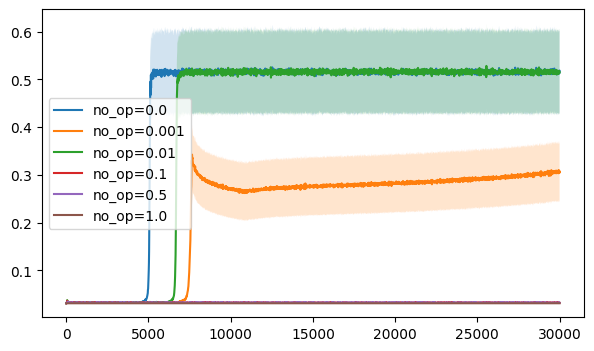

In [ ]:
# plot all the curves
for no_op, logs in RESULTS.items():
    steps = sorted(logs.keys())
    max_attns = [logs[s]['avg_attn'].max() for s in steps]
    stds_attns = [logs[s]['avg_attn'].std() for s in steps]
    plt.fill_between(steps,
                     np.array(max_attns) - np.array(stds_attns),
                     np.array(max_attns) + np.array(stds_attns),
                     alpha=0.2)
    plt.plot(steps, max_attns, label=f'no_op={no_op}')
plt.legend()
plt.show()

In [ ]:
import matplotlib

def fontsize(mult):
  matplotlib.rcParams.update({'font.size': 12 * mult})

import scipy
import matplotlib as mpla
import seaborn as sns

matplotlib.rcdefaults()

colors_by_tone = {
    50:  ["#eff6ff", "#f0fdf4", "#f5f3ff", "#fefce8", "#fdf2f8", "#f0fdfa", "#fef2f2"],
    100: ["#dbeafe", "#dcfce7", "#ede9fe", "#fef9c3", "#fce7f3", "#ccfbf1", "#fee2e2"],
    200: ["#bfdbfe", "#bbf7d0", "#ddd6fe", "#fef08a", "#fbcfe8", "#99f6e4", "#fecaca"],
    300: ["#93c5fd", "#86efac", "#c4b5fd", "#fde047", "#f9a8d4", "#5eead4", "#fca5a5"],
    400: ["#60a5fa", "#4ade80", "#a78bfa", "#facc15", "#f472b6", "#2dd4bf", "#f87171"],
    500: ["#3b82f6", "#22c55e", "#8b5cf6", "#eab308", "#ec4899", "#14b8a6", "#ef4444"],
    600: ["#2563eb", "#16a34a", "#7c3aed", "#ca8a04", "#db2777", "#0d9488", "#dc2626"],
    700: ["#1d4ed8", "#15803d", "#6d28d9", "#a16207", "#be185d", "#0f766e", "#b91c1c"],
    800: ["#1e40af", "#166534", "#5b21b6", "#854d0e", "#9d174d", "#115e59", "#991b1b"],
    900: ["#1e3a8a", "#14532d", "#4c1d95", "#713f12", "#831843", "#134e4a", "#7f1d1d"],
}

In [ ]:
no_ops_values

[0.0, 0.001, 0.01, 0.1, 0.5, 1.0]

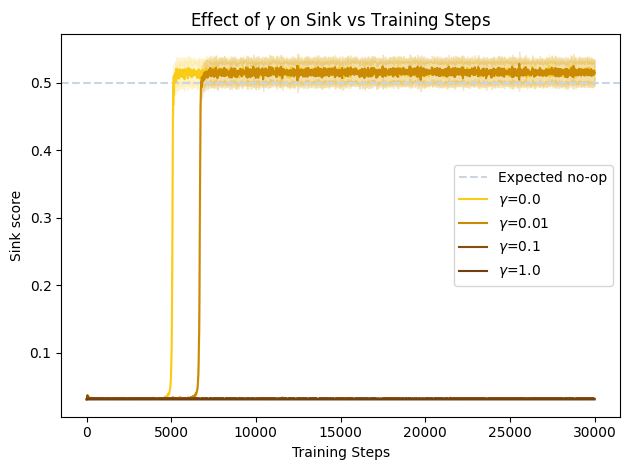

In [ ]:
color_index = 3
#no_ops_values = sorted(RESULTS.keys())
no_ops_values = [0.0, 0.01, 0.1, 1.0]

def id_to_tone(idx):
    return [400, 600, 800, 900][idx % 4]

# add grey baseline at y = 0.5 which is the number of token to be nulled out
plt.axhline(y=0.5, color='#cbd5e1', linestyle='--', label='Expected no-op')

for no_op in no_ops_values:
    color = colors_by_tone[id_to_tone(no_ops_values.index(no_op))][color_index]
    logs = RESULTS[no_op]
    steps = sorted(logs.keys())
    max_attns = [logs[s]['avg_attn'].max() for s in steps]
    stds_attns = [logs[s]['avg_attn'].std() for s in steps]
    plt.fill_between(steps,
                     np.array(max_attns) - np.array(stds_attns) / 5.0,
                     np.array(max_attns) + np.array(stds_attns) / 5.0,
                     color=color, alpha=0.2)
    plt.plot(steps, max_attns, label=f'$\gamma$={no_op}', c=color)
plt.legend()
plt.title("Effect of $\gamma$ on Sink vs Training Steps")
plt.xlabel("Training Steps")
plt.ylabel("Sink score")
plt.tight_layout()
plt.savefig('figs/sink_vs_no_op_factor.pdf', dpi=400, transparent=True, bbox_inches='tight', pad_inches=0.01)
plt.show()

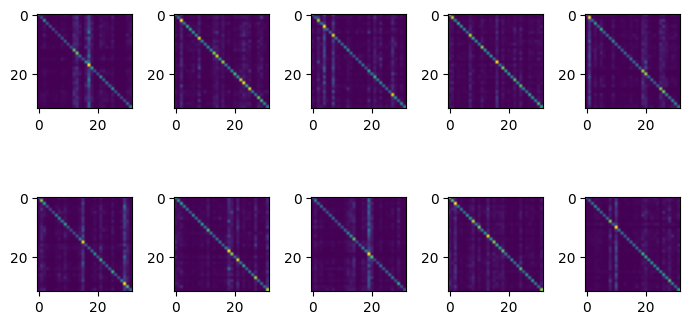

step 20000 | loss 8.455e-02 | mean attn→pos0 0.032


In [ ]:
def train_and_logs2(threshold_factor = 0.0,   BATCH_SIZE=2048, STEPS=30_000):

  LOGS = {}

  device = "cuda"

  model = OneHead().to(device)
  opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

  # fixed gate vector v (no grad)
  v_gate = torch.randn(DMODEL, device=device)
  v_gate = v_gate / v_gate.norm()  # normalize just for stability

  for step in range(1, STEPS + 1):
      # random token embeddings
      x = torch.randn(BATCH_SIZE, SEQ_LEN, DMODEL, device=device)

      O, A, (Q, K, V, scores, x_in, x_after_posln) = model(x, ret=True)

      # compute s = <x_in, v_gate> for each token
      # x_in: (B, L, d), v_gate: (d,) -> (B, L, 1)
      s = (x_in * v_gate).sum(dim=-1, keepdim=True)

      mask = (s > threshold_factor).float()
      # when the mask is active results should be x_in * no_op_factor else just x_in
      target = mask * (x_in * 0.0) + (1.0 - mask) * x_in  # (B, L, d)
      #old target = (1.0 - mask) * x_in  # (B, L, d)

      loss = F.mse_loss(O, target)

      opt.zero_grad(set_to_none=True)
      loss.backward()
      opt.step()

      if step % 10 == 0:
          avg_attn = measure_avg_attention(model)
          LOGS[step] = {
              'avg_attn': avg_attn.numpy(),
          }

      if step % 10_000 == 0:
          # imshow the attention of the first ten input
          set_size(7, 4)
          for i in range(10):
              a = A[i].detach().cpu().numpy()  # (L, L)
              plt.subplot(2, 5, i + 1)
              plt.imshow(a, cmap='viridis')
          plt.tight_layout()
          plt.show()

          attn_to_0 = A[..., 0].mean().item()
          print(
              f"step {step:5d} | loss {loss.item():.3e} | "
              f"mean attn→pos0 {attn_to_0:.3f}"
          )

  return LOGS

def prob_to_thresh(probability, dim):
    from scipy.stats import norm
    # For standard normal, find z such that P(Z > z) = p
    z = norm.ppf(1 - probability)
    # The distribution of <x, v> where x ~ N(0, I_d) and v is unit vector is N(0, 1)
    # So the threshold is simply z
    return z

RESULTS2 = {}
lambdas = [prob_to_thresh(prob, DMODEL) for prob in np.linspace(0.1, 0.9, 20)]
lambdas = lambdas[::-1]
for thresh in lambdas:
  logs = train_and_logs2(threshold_factor=thresh, BATCH_SIZE=2048, STEPS=20_000)
  RESULTS2[thresh] = logs

In [ ]:
torch.save(RESULTS2, "data/toy_lambda_factor.pt")

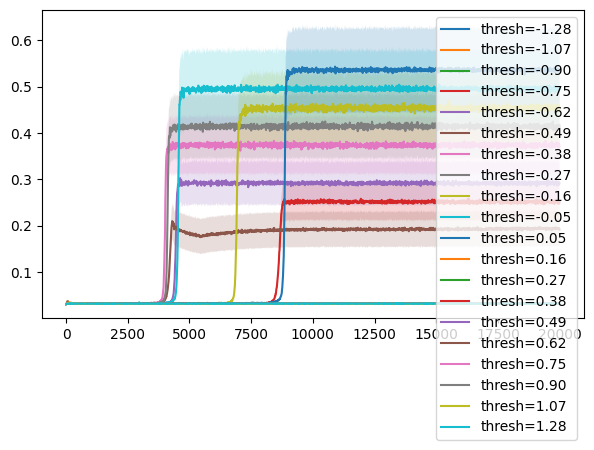

In [ ]:
# plot the results
for thresh, logs in RESULTS2.items():
    steps = sorted(logs.keys())
    max_attns = [logs[s]['avg_attn'].max() for s in steps]
    stds_attns = [logs[s]['avg_attn'].std() for s in steps]
    plt.fill_between(steps,
                     np.array(max_attns) - np.array(stds_attns),
                     np.array(max_attns) + np.array(stds_attns),
                     alpha=0.2)
    plt.plot(steps, max_attns, label=f'thresh={thresh:.2f}')
plt.legend()
plt.show()


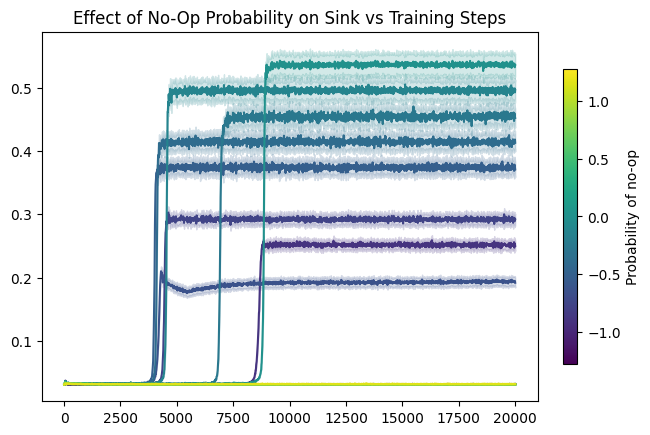

In [ ]:
thresholds = sorted(RESULTS2.keys())
#cmap = plt.get_cmap("managua")
cmap = plt.get_cmap("viridis")

for thresh, logs in RESULTS2.items():
    thresh_to_prob = scipy.stats.norm.sf(thresh)
    color = cmap(thresholds.index(thresh) / len(thresholds))
    steps = sorted(logs.keys())
    max_attns = [logs[s]['avg_attn'].max() for s in steps]
    stds_attns = [logs[s]['avg_attn'].std() for s in steps]
    plt.fill_between(steps,
                     np.array(max_attns) - np.array(stds_attns) / 5.0,
                     np.array(max_attns) + np.array(stds_attns) / 5.0,
                     alpha=0.2, color=color)
    plt.plot(steps, max_attns, color=color)
# create a colorbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=thresholds[0], vmax=thresholds[-1]))
sm.set_array([])
cbar = plt.colorbar(sm, cax=plt.gca().inset_axes([1.05, 0.1, 0.03, 0.8]))
cbar.set_label('Probability of no-op')
#plt.legend()
plt.title("Effect of No-Op Probability on Sink vs Training Steps")
plt.savefig('figs/sink_vs_proba_no_op.pdf', dpi=400, transparent=True, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [ ]:
# Now collect the interaction matrix W_q W_k and study the spectral signature of the sink vs no sink models

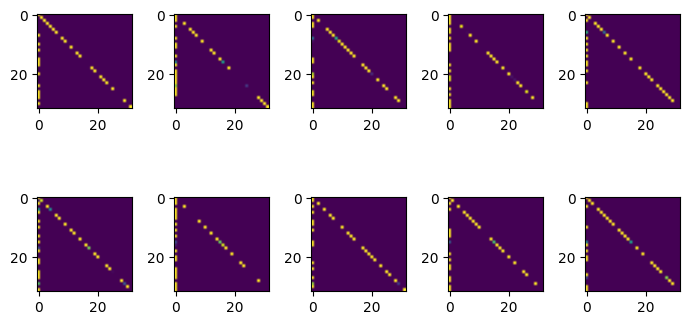

step 10000 | loss 4.758e-02 | mean attn→pos0 0.518


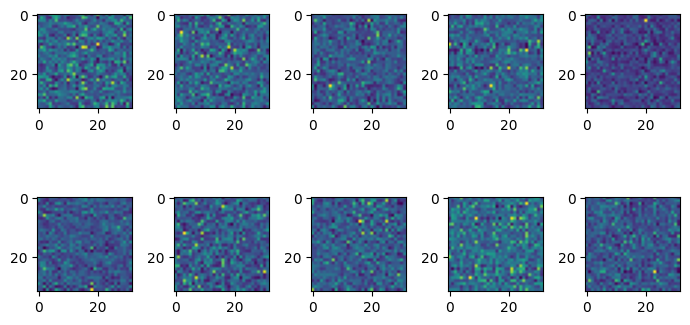

step 10000 | loss 2.348e-02 | mean attn→pos0 0.031


In [ ]:
def train_and_logs3(threshold_factor = 0.0,   BATCH_SIZE=2048, STEPS=30_000):

  LOGS = {}

  device = "cuda"

  model = OneHead().to(device)
  opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

  # fixed gate vector v (no grad)
  v_gate = torch.randn(DMODEL, device=device)
  v_gate = v_gate / v_gate.norm()  # normalize just for stability

  for step in range(1, STEPS + 1):
      # random token embeddings
      x = torch.randn(BATCH_SIZE, SEQ_LEN, DMODEL, device=device)

      O, A, (Q, K, V, scores, x_in, x_after_posln) = model(x, ret=True)

      # compute s = <x_in, v_gate> for each token
      # x_in: (B, L, d), v_gate: (d,) -> (B, L, 1)
      s = (x_in * v_gate).sum(dim=-1, keepdim=True)

      mask = (s > threshold_factor).float()
      # when the mask is active results should be x_in * no_op_factor else just x_in
      target = mask * (x_in * 0.0) + (1.0 - mask) * x_in  # (B, L, d)
      #old target = (1.0 - mask) * x_in  # (B, L, d)

      loss = F.mse_loss(O, target)

      opt.zero_grad(set_to_none=True)
      loss.backward()
      opt.step()

      if step % 10 == 0:
          avg_attn = measure_avg_attention(model)
          LOGS[step] = {
              'avg_attn': avg_attn.numpy(),
          }

      if step % 10_000 == 0:
          # imshow the attention of the first ten input
          set_size(7, 4)
          for i in range(10):
              a = A[i].detach().cpu().numpy()  # (L, L)
              plt.subplot(2, 5, i + 1)
              plt.imshow(a, cmap='viridis')
          plt.tight_layout()
          plt.show()

          attn_to_0 = A[..., 0].mean().item()
          print(
              f"step {step:5d} | loss {loss.item():.3e} | "
              f"mean attn→pos0 {attn_to_0:.3f}"
          )

  return LOGS, model.eval().cpu()

RESULTS3 = {}

# train just one sink and one no sink
logs_sink, sink_model = train_and_logs3(threshold_factor = 0.0, BATCH_SIZE=2048, STEPS=10_000)
logs_no_sink, no_sink_model = train_and_logs3(threshold_factor = 10.0, BATCH_SIZE=2048, STEPS=10_000)

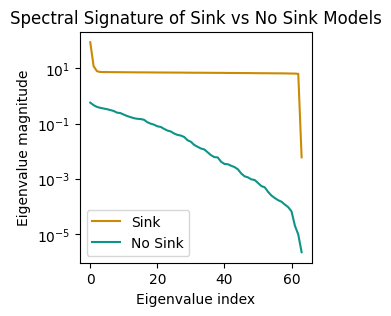

In [ ]:
# Get the Wk and Wq matrices
Wq_sink = sink_model.Wq.weight.data.cpu().numpy()  # (H, D)
Wk_sink = sink_model.Wk.weight.data.cpu().numpy()  # (H, D)
Wq_no_sink = no_sink_model.Wq.weight.data.cpu().numpy()  # (H, D)
Wk_no_sink = no_sink_model.Wk.weight.data.cpu().numpy()  # (H, D)

def spectral_signature(Wq, Wk, **kwargs):
    W = Wq @ Wk.T  # (H, H)
    # do svd
    svd = np.linalg.svd(W, full_matrices=False)
    eigvals = svd[1]

    # plot them
    plt.plot(np.abs(eigvals.real), **kwargs)
    return eigvals

set_size(3, 3)
eig_sink = spectral_signature(Wq_sink, Wk_sink, label="Sink", color='#ca8a04')
eig_no_sink = spectral_signature(Wq_no_sink, Wk_no_sink, label="No Sink", color='#0d9488')
plt.yscale("log")
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue magnitude")
plt.title("Spectral Signature of Sink vs No Sink Models")
plt.legend()
plt.savefig('figs/spectral_signature_sink_vs_no_sink.pdf', dpi=400, transparent=True, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [ ]:
eig_no_sink

array([5.68108737e-01, 4.62046415e-01, 3.98349971e-01, 3.69453162e-01,
       3.48592401e-01, 3.30191731e-01, 3.06640506e-01, 2.83843100e-01,
       2.47549593e-01, 2.38504648e-01, 2.10521117e-01, 1.86569765e-01,
       1.70588464e-01, 1.56624258e-01, 1.48426071e-01, 1.45357683e-01,
       1.37260005e-01, 1.11983627e-01, 9.91334915e-02, 9.12250876e-02,
       7.95934573e-02, 7.54203051e-02, 6.44010976e-02, 5.58035970e-02,
       5.17734177e-02, 4.36791442e-02, 3.89123112e-02, 3.68229412e-02,
       3.27077769e-02, 2.50247829e-02, 2.19469797e-02, 1.68406237e-02,
       1.44872023e-02, 1.25189526e-02, 1.15956105e-02, 9.14766546e-03,
       7.19209574e-03, 6.14458229e-03, 5.97980386e-03, 4.16755956e-03,
       3.48185981e-03, 3.38992500e-03, 2.98956782e-03, 2.68317503e-03,
       2.22553429e-03, 1.57448009e-03, 1.24168978e-03, 1.13850797e-03,
       9.64475737e-04, 9.15209996e-04, 7.14814407e-04, 5.53183258e-04,
       4.97796049e-04, 3.41350329e-04, 2.51518359e-04, 2.04872820e-04,
      

In [ ]:
eig_no_sink

array([-1.52015314e-01+1.98193461e-01j, -1.52015314e-01-1.98193461e-01j,
       -2.19141737e-01+1.09623566e-01j, -2.19141737e-01-1.09623566e-01j,
        9.41492245e-02+2.18527272e-01j,  9.41492245e-02-2.18527272e-01j,
        1.88196182e-01+9.94650200e-02j,  1.88196182e-01-9.94650200e-02j,
        1.74049884e-01+0.00000000e+00j,  1.35592401e-01+8.19214657e-02j,
        1.35592401e-01-8.19214657e-02j, -1.50467962e-01+0.00000000e+00j,
       -5.35109490e-02+1.14077017e-01j, -5.35109490e-02-1.14077017e-01j,
        1.14426218e-01+4.05501425e-02j,  1.14426218e-01-4.05501425e-02j,
       -1.11648172e-01+0.00000000e+00j,  2.83581614e-02+9.46808308e-02j,
        2.83581614e-02-9.46808308e-02j, -7.87978992e-02+4.57611084e-02j,
       -7.87978992e-02-4.57611084e-02j, -6.63286597e-02+0.00000000e+00j,
        1.14399462e-03+5.98584749e-02j,  1.14399462e-03-5.98584749e-02j,
        4.45688218e-02+3.35866697e-02j,  4.45688218e-02-3.35866697e-02j,
        3.94906998e-02+2.92222798e-02j,  3.94906998